# Tutorial 2: Trajectory Inference using Cellrank

## Introduction 
ATLAS is a multi-omics framework that supports Trajectory Inference (TI) on multi-omics data. ATLAS is build upon estimated TI tools for trajectory inference such as Palantir {cite}`palantir` and CellRank {cite}`cellrank2`. 

In this set of tutorials, you will learn how to: 
- Construct a multimodal container with two or mode modalities and preprocess it with ATLAS. 
- Perform trajectory inference using Palantir as underlying TI strategy.
- Perform trajecotry inference unsing CellRank as underlying TI strategy.
- Evaluate results from the trajectory inference.
- Perform multimodal plots.

In this tutorial we analyze a multimodal SHARE-seq dataset of mouse hair follicle cells {cite}`shareseq`. 

The dataset includes `hair follicle stem cells` (HFSCs), `transit-amplifying cells` (TACs), and their differentiated progeny along multiple lineages, such as the `hair-shaft medulla`, the  `hair-shaft cuticle cortex` and the `inner root sheat`  (IRS), making it an ideal benchmark for multimodal trajectory inference.

The {class}`muon.MuData` object is already preprocessed and contains two modalities: `rna` with gene expression values and `activity` with gene activity values. Preprocessing followed similar computations as illustrated in Tutorial 1 and is available [at this link](https://github.com/smilies-polito/atlas-experiments). 

In [2]:
import os
import atlas
import muon as mu
import numpy as np
import pandas as pd


seed = 42
rng = np.random.default_rng(seed)
np.random.seed(seed)
n_states = 6


data_path = os.path.join(os.getcwd(), "data")
initial_data = mu.read_h5mu(os.path.join(data_path, "hair.h5mu"))
pseudotime = pd.read_csv(os.path.join(data_path, "pseudotime.csv"), header=None, index_col=0)
pseudotime.columns = ["pseudotime"]

initial_data.obs = initial_data.obs.merge(pseudotime, left_index=True, right_index=True, how="left")

/Users/lrcq/atlas-paper/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/lrcq/atlas-paper/.venv/lib/python3.14/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):
/Users/lrcq/atlas-paper/.venv/lib/python3.14/site-packages/mudata/_core/mudata.py:988: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=1, join_common=join_common)


We now need to obtain the Weighted Nearest Neighbor (WNN) graph {cite}`wnn` as explained in Tutorial 1. We exploit ATLAS preprocessing function to create the WNN and UMAP. 

/Users/lrcq/atlas-paper/.venv/lib/python3.14/site-packages/mudata/_core/mudata.py:988: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=1, join_common=join_common)
/Users/lrcq/atlas-paper/.venv/lib/python3.14/site-packages/mudata/_core/mudata.py:988: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=1, join_common=join_common)


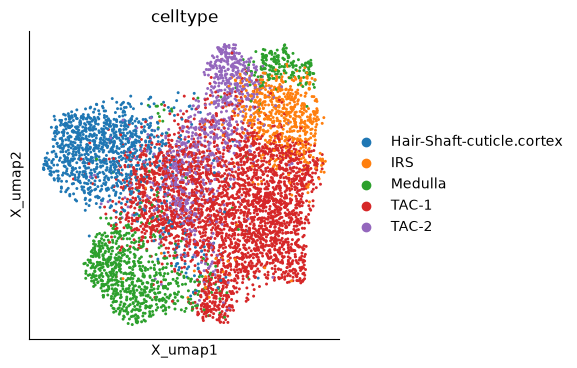

In [3]:
mudata = atlas.pp.wnn(
    mudata=initial_data, knn=15, n_pcs={"rna": 20, "activity": 10}, n_neighbors=None, random_state=seed, copy=True
)
_ = atlas.tl.umap(mudata=mudata, random_state=seed)
mu.pl.embedding(mudata, basis="X_umap", color=["celltype"])

## Trajectory Inference Using ATLAS

This tutorial focuses on:
- Performing TI with ATLAS using `CellRank` as the underlying strategy.
- Visualizing the TI results.
- Perform multimodal visualisations
- Applying unsupervised metrics defined in ATLAS to assess the confidence of the inferred trajectory.


CellRank {cite}`cellrank2`, in its Pseudotime-Kernel implementation, orients the cell-cell graph using precomputed pseudotime values and then applies Generalized Perron Cluster Cluster Analysis (GPCCA) to the resulting manifold to identify macrostates. Its underlying assumption is that, during development, cell state changes are incremental: one expects to observe small, gradual transitions rather than abrupt jumps. Under this assumption, a K-nearest-neighbor (KNN) graph built on single-cell data is able to reconstruct a manifold that connects cells with similar expression states, thereby capturing cell state evolution.

ATLAS extends CellRank's capabilities to multi-omics data, based on the consideration that development is driven not only by gene expression, but also by the underlying regulatory mechanisms. Consequently, ATLAS TI (CellRank-based) generalizes the original assumption of incremental cell state changes to a manifold that incorporates complementary information about gene regulation.

From the perspective of this tutorial, ATLAS extends the CellRank Pseudotime Kernel to MuData objects through the {class}`~atlas.tl.CellRankExtension` class. The extended functionalities include:
- Computation of the transition matrix
- Schur decomposition of the dynamics
- Identification of macrostates using GPCCA
- Identification of initial, intermediate, and terminal macrostates, together with cell-fate probabilities

Mathematical details about CellRank are described in the original publication {cite}`cellrank1`.

Note that we installed `petsc4py` and `slepc4py`. 

In [4]:
cex = atlas.tl.CellRankExtension(mudata=mudata)
cex.compute_kernel(key="wnn", time_key="pseudotime", cluster_key="celltype", n_jobs=1, backend="threading")

cex.run(n_states=n_states, use_petsc=True, allow_overlap=False, backend="threading", n_jobs=1)

INFO     Computing transition matrix based on pseudotime                                                           


100%|██████████| 6649/6649 [00:00<00:00, 15286.64cell/s]


INFO         Finish (0.68s)                                                                                        
INFO     Computing Schur decomposition                                                                             
INFO     When computing macrostates, choose a number of states NOT in ``                                           
INFO     Adding `adata.uns['eigendecomposition_fwd']`                                                              
                `.schur_vectors`                                                                                   
                `.schur_matrix`                                                                                    
                `.eigendecomposition`                                                                              
             Finish (0.58s)                                                                                        
INFO     Computing 6 macrostates                                        

100%|██████████| 4/4 [00:00<00:00, 34.66/s]

INFO     Adding `adata.obsm['lineages_fwd']`                                                                       
                `.fate_probabilities`                                                                              
             Finish (0.13s)                                                                                        


{class}`~atlas.tl.CellRankExtension` accepts as input the multiomics instance and applies kernel computation. The {meth}`~atlas.tl.CellRankExtension.run` method computes pseudotime and cell-wise fate probabilites.

The multimodal object now stores additional results: 
- Two columns containing entropy measures are added to the `.obs` slot, namely `shannon_entropy` and `kl_divergence`. These are mesurements for cell plasticity. 
- `initial_states`, `macrostates` and `terminal_states` are added to the `.obs` slot. These contain the list of identifies terminal and initial states adn well as all identified macrostates.
- `fate_state_colors` is added to the `.uns` slot stores colors for all macrostates. Similarly, `initial_states_colors`, `terminal_states_colors` and `marostates_colors` are added as well.
- `fate_probabilities` is added to the `.obsm` slot. These are the cell fate probabilities towards the inferred branches. 

In [8]:
mudata.write(os.path.join(os.getcwd(), "data", "ti.h5mu"))